## Task 1....


In [77]:
import matplotlib.pyplot as plt
import pandas as pd

In [78]:
df = pd.read_csv('customer_shopping_data.csv')
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [79]:
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')

In [80]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%d/%m/%Y')
df['month'] = df['invoice_date'].dt.month
df['year'] = df['invoice_date'].dt.year
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,month,year
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,8,2022
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,12,2021
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,11,2021
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,5,2021
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,10,2021


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  object        
 1   customer_id     99457 non-null  object        
 2   gender          99457 non-null  object        
 3   age             99457 non-null  int64         
 4   category        99457 non-null  object        
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  object        
 8   invoice_date    99457 non-null  datetime64[ns]
 9   shopping_mall   99457 non-null  object        
 10  month           99457 non-null  int32         
 11  year            99457 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(2), int64(2), object(6)
memory usage: 8.3+ MB


In [82]:
month_sales_df = df.groupby('month')['price'].sum()
month_sales_df

month
1     7932626.63
2     7235297.32
3     6007346.21
4     5102478.76
5     5346926.82
6     5160345.74
7     5552023.57
8     5270542.03
9     5115214.27
10    5538258.09
11    4995141.11
12    5295165.36
Name: price, dtype: float64

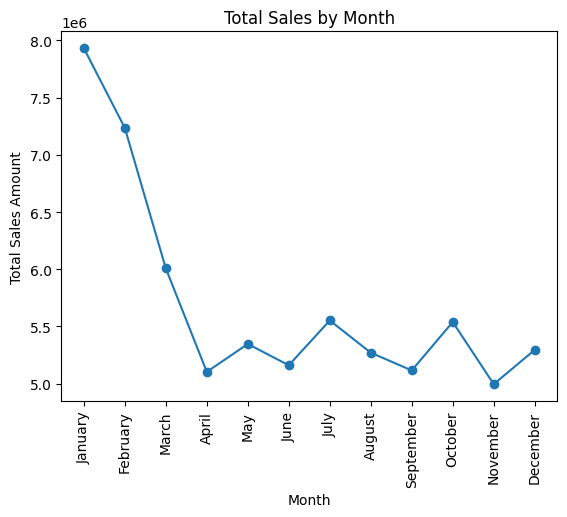

In [83]:
### using matplotlib to plot the total sales by month as a line chart


month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

x = month_sales_df.index

# y values (sales)
y = month_sales_df.values.flatten()   # change column name if different

plt.figure()

plt.plot(x, y, marker='o')

plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')

plt.xticks(x, [month_names[i-1] for i in x], rotation=90)

plt.show()

## Task 2....


In [84]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,month,year
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,8,2022
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,12,2021
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,11,2021
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,5,2021
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,10,2021


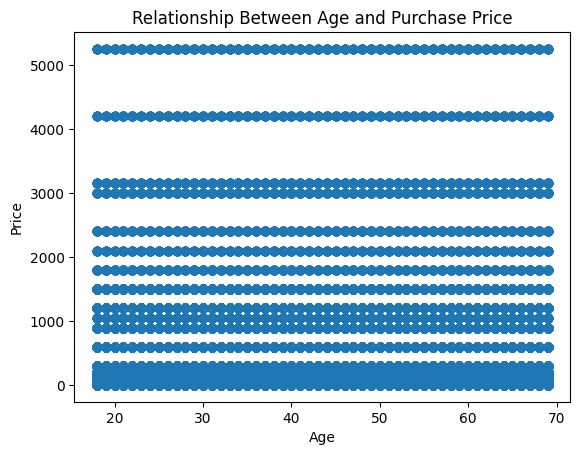

In [85]:
## scatter plot of sales amount vs month
x = df['age']
y = df['price']

plt.figure()

plt.scatter(x, y)

plt.title("Relationship Between Age and Purchase Price")
plt.xlabel("Age")
plt.ylabel("Price")

plt.show()


## Task 3...

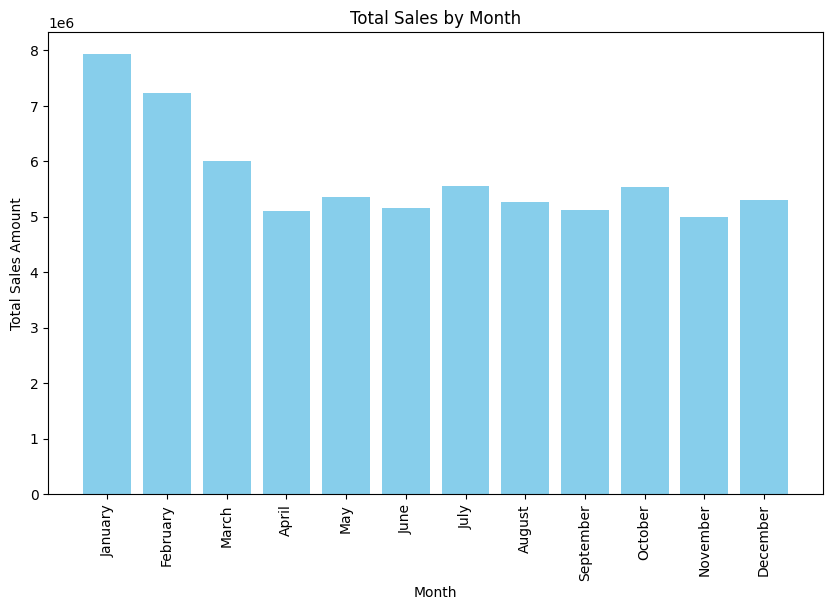

In [86]:
## vertical bar chart
month_names = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(10,6))

plt.bar(month_sales_df.index, month_sales_df.values.flatten(), color='skyblue')

plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')

plt.xticks(month_sales_df.index, [month_names[i-1] for i in month_sales_df.index], rotation=90)

plt.show()

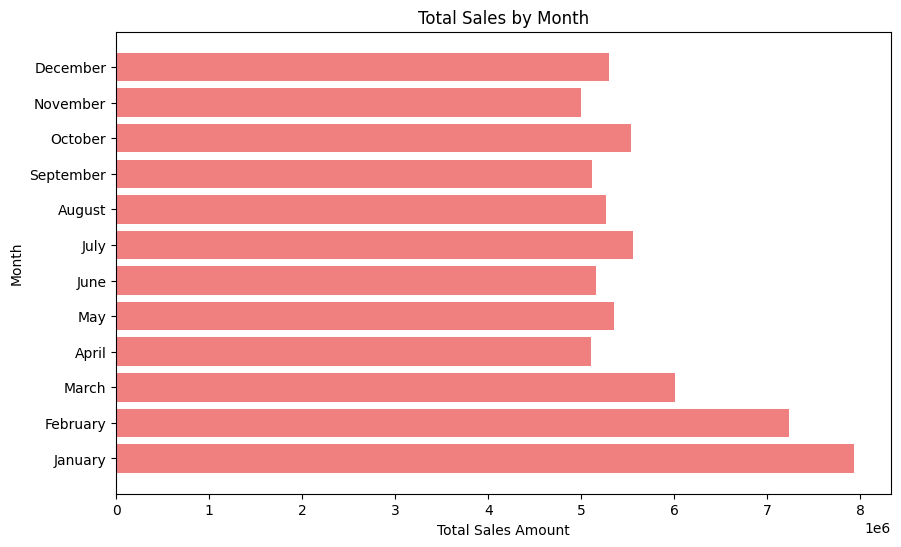

In [87]:
## Horizontal bar chart
month_names = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(10,6))

plt.barh(month_sales_df.index, month_sales_df.values.flatten(), color='lightcoral')

plt.title('Total Sales by Month')
plt.xlabel('Total Sales Amount')
plt.ylabel('Month')

plt.yticks(month_sales_df.index, [month_names[i-1] for i in month_sales_df.index])

plt.show()

## Task 4...

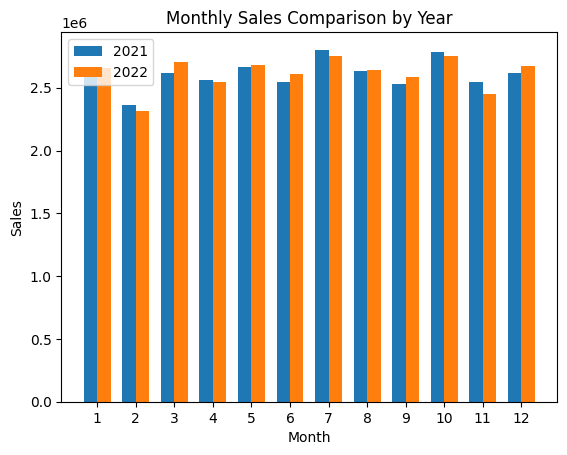

In [88]:
## multiple bar chart camparing sales in matplot lib 
import numpy as np
sales_data = df.groupby(['year','month'])['price'].sum().unstack()

months = sales_data.columns

year1 = sales_data.loc[2021]
year2 = sales_data.loc[2022]

x = np.arange(len(months))
width = 0.35

plt.figure()

plt.bar(x - width/2, year1, width, label='2021')
plt.bar(x + width/2, year2, width, label='2022')

plt.title("Monthly Sales Comparison by Year")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(x, months)

plt.legend()

plt.show()

## Task 5...

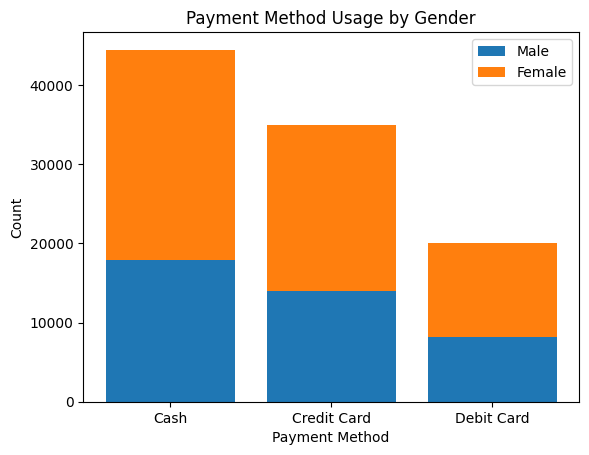

In [89]:
##  stacked bar chart in mat plot lib comparing sales by month and year
stack_data = df.groupby(['gender','payment_method']).size().unstack()

methods = stack_data.columns

male = stack_data.loc['Male']
female = stack_data.loc['Female']

plt.figure()

plt.bar(methods, male, label="Male")
plt.bar(methods, female, bottom=male, label="Female")

plt.title("Payment Method Usage by Gender")
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.legend()

plt.show()


## Task 6...


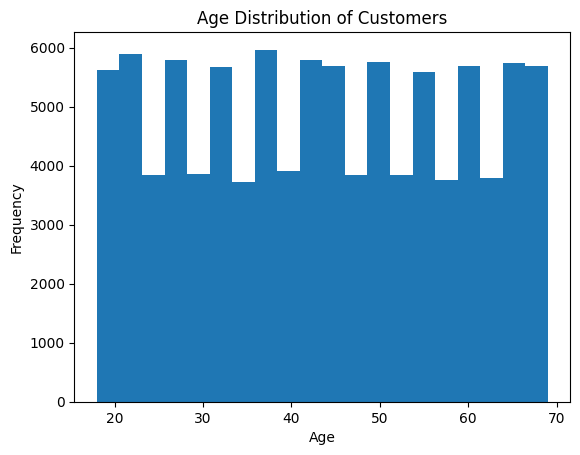

In [90]:
## histogram of sales amount
ages = df['age']
plt.figure()
plt.hist(ages, bins=20)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## Task 7...

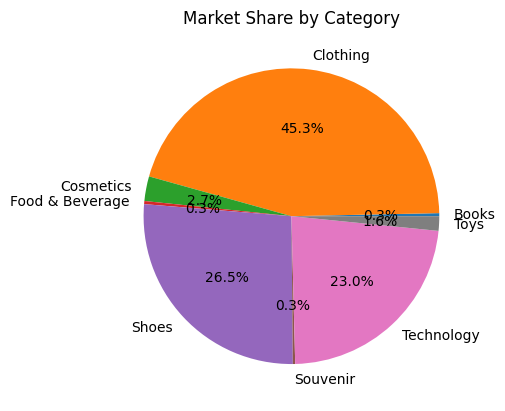

In [91]:
###pie chart representing category
category_share = df.groupby('category')['price'].sum()

labels = category_share.index
sizes = category_share.values

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Market Share by Category")
plt.show()